# Homework: Build a StationXML Inventory for recent KSC deployment

Seven USF stations were deployed at Kennedy Space Center between January 7-12, 2026.
* Each features a Nanometrics Centaur digitizer, and a Nanometrics Trillium Compact Post-Hole 120-s seismometer.
* This is the same equipment we setup in our class a few weeks ago - except we also had infrasound.

Three additional seismic stations were setup by Marshall Space Flight Center, using Guralp and Silicon Audio equipment. You can ignore those for this exercise - or potentially earn some bonus points if you find responses for those too!

## Goal
Create a valid **StationXML** file for this small network using:
- Station coordinates stored in an **Excel** file
- Instrument responses pulled from the **IRIS Nominal Response Library (NRL)**

You will:
1. Load the station list with **pandas** into a pandas DataFrame
2. Create a Response object for a USF Nanometrics station
3. Build an ObsPy **Inventory**
4. Write out a **StationXML** file

> We're keeping it simple: one network, three channels per station (Z, N, E), same equipment at each site.

**Warning:** only attempt this homework after you have completed this week's reading exercises (notebooks 73 and 74)

## Provided file
Your station list is in:

- `Summary_Seismic_Station_List.xlsx`

One column contains photos — **ignore it**.

An alternative version of the Excel file is also provided as a Comma-Separated-Variable (CSV) text file, just in case you cannot read the Excel file. This is easier to read.

(If you open any Excel file with Excel, you can save it as a CSV).

## Make sure you have openpyxl installed in your conda environment!
This is required to read Excel files. CSV files will work without it.

In [2]:
#import sys
#!conda install -y openpyxl --prefix {sys.prefix}

## Minimal pandas intro (what you need today)

**pandas** is a Python library for working with tables (“dataframes”).  
For this homework you only need to:
- read an Excel file
- select a few columns
- loop over rows

**Note**: you may need to install openpyxl in conda, and then restart this notebook/kernel. At the command line:

```
conda activate compsci # or whatever your conda env is
conda install openpyxml
```

In [3]:
import pandas as pd

xlsx_path = r"Summary_Seismic_Station_List.xlsx"
df = pd.read_excel(xlsx_path)

df.head(10)

,Site Name,GPS Coordinates,Photo,lat,lon,Notes,Digitizer,Seismometer,Infrasound
0,B01,"28°37'17""N 80°36'24""W",NaN,28.621389,-80.606667,Seismic (nanometrics) #271. Infrasound (other)...,Centaur (271),NaN,"infraBSU (268, 412, 453)"
1,B03,"28°38'34""N 80°37'25""W",NaN,28.642778,-80.623611,Sensor ~100ft from Eagle 4 tower on dune. Seis...,NaN,Trillium C-PH120 (2663),infraBSU (417)
2,B05,"28°38'24""N 80°38'42""W",NaN,28.640000,-80.645000,Sensor in front of Helipad 9 sign. Seismic (na...,Centaur (386),Trillium C-PH120 (2392),infraBSU (414)
3,B07,"28°36'26""N 80°35'39""W",NaN,28.607222,-80.594167,Sensor (Guralp) #00B68. IPv4 169.254.168.11,Certimus (00B68),NaN,NaN
4,B12,"28°37'18""N 80°38'50""W",NaN,28.621667,-80.647222,Sensor located off Happy Creek Rd. Guralp Cert...,Certimus (00D68),NaN,NaN
5,B14,"28°37'56""N 80°36'57""W",NaN,28.632222,-80.615833,Seismic (nanometrics) #2719. Infrasound x3 - #...,Centaur (383),Trillium C-PH120 (2719),"infraBSU (292, 461, 336)"
6,B20,"28°34'25""N 80°34'20""W",NaN,28.573611,-80.572222,Sensor located 20 ft 195degrees from north. Se...,Centaur (384),NaN,"M25 (071975), infraBSU (403)"
7,B23,"28°34'43""N 80°36'28""W",NaN,28.578611,-80.607778,Sensor (gain set to 5 Vpp). SA #the only one w...,NaN,Silicon Audio,NaN
8,B24,"28°34'50""N 80°38'27""W",NaN,28.580556,-80.640833,Seismic (nanometrics) #2619. Infrasound #0224....,Centaur (166),Trillium C-PH120 (2619),infraBSU (224)
9,B29,"28°37'05""N 80°40'37""W",NaN,28.618056,-80.676944,Site of controlled burn. Station watered to sa...,Centaur (202),Trillium C-PH120 (2410),infraBSU (436)


If for any reason you cannot load the Excel file, you can try the CSV file instead:
```
df = pd.read_csv("Summary_Seismic_Station_List.csv")
```

In [4]:
df.columns

Index(['Site Name', 'GPS Coordinates', 'Photo', 'lat', 'lon', 'Notes',
       'Digitizer', 'Seismometer', 'Infrasound'],
      dtype='object')

## Step 1 — Keep only the columns we need

For StationXML, we need at minimum:
- station code (name)
- latitude
- longitude

We will also keep:
- seismometer model (if present)
- digitizer model (if present)

In [5]:
use_cols = ["Site Name", "lat", "lon", "Seismometer", "Digitizer"]
stations = df[use_cols].copy()

# Ignore the Photo column (already excluded)
stations

,Site Name,lat,lon,Seismometer,Digitizer
0,B01,28.621389,-80.606667,NaN,Centaur (271)
1,B03,28.642778,-80.623611,Trillium C-PH120 (2663),NaN
2,B05,28.640000,-80.645000,Trillium C-PH120 (2392),Centaur (386)
3,B07,28.607222,-80.594167,NaN,Certimus (00B68)
4,B12,28.621667,-80.647222,NaN,Certimus (00D68)
5,B14,28.632222,-80.615833,Trillium C-PH120 (2719),Centaur (383)
6,B20,28.573611,-80.572222,NaN,Centaur (384)
7,B23,28.578611,-80.607778,Silicon Audio,NaN
8,B24,28.580556,-80.640833,Trillium C-PH120 (2619),Centaur (166)
9,B29,28.618056,-80.676944,Trillium C-PH120 (2410),Centaur (202)


In [22]:
from obspy.clients.nrl import NRL
nrl = NRL()

print(nrl.sensors['Nanometrics'].keys())
print(nrl.sensors['Nanometrics']['Trillium Compact 120 (Vault, Posthole, OBS)'].keys())
print(nrl_client.dataloggers['Nanometrics']['Centaur'].keys())

dict_keys(['Titan Accelerometer', 'Meridian Posthole', 'Meridian Compact Posthole', 'Trillium 40', 'Trillium 120P/PA', 'Trillium 120Q/QA,PH,BH (Vault, Posthole or Borehole)', 'Trillium 120 Horizon', 'Trillium Compact 20 (Vault, Posthole, OBS)', 'Trillium Compact 120 (Vault, Posthole, OBS)', 'Trillium All-Terrain', 'Trillium Cascadia seismometer', 'Trillium Cascadia Accelerometer', 'Trillium 240', 'Trillium 360'])
dict_keys(['754 V/m/s', '1500 V/m/s', '2000 V/m/s'])
dict_keys(['40 Vpp (1)', '20 Vpp (2)', '10 Vpp (4)', '4 Vpp (10)', '2 Vpp (20)', '1 Vpp (40)'])


C:\Users\jacob\AppData\Local\Temp\ipykernel_26284\2006746024.py:2: ObsPyDeprecationWarning: 
        DEPRECATED

        Direct access to online NRL is deprecated as it will stop working when
        the original NRLv1 gets taken offline (Spring 2023), please consider
        working locally with a downloaded full copy of the old NRLv1 or new
        NRLv2 following instructions on the
        `NRL landing page <https://ds.iris.edu/ds/nrl/>`_.
        
  nrl = NRL()


## Step 2 — Create a Response object for a USF Nanometrics station

In [25]:
from obspy.clients.nrl import NRL

nrl = NRL()

sensor_keys = ["Nanometrics", "Trillium Compact 120 (Vault, Posthole, OBS)", "754 V/m/s"]
datalogger_keys = ["Nanometrics", "Centaur", "40 Vpp (1)", "Off", "Linear phase", "100"]

resp_combined = nrl.get_response(datalogger_keys=datalogger_keys, sensor_keys=sensor_keys)
resp_sensor, _ = nrl._get_response("sensors", keys=sensor_keys)
resp_digitizer, _ = nrl._get_response("dataloggers", keys=datalogger_keys)
print("Combined response:", resp_combined)

C:\Users\jacob\AppData\Local\Temp\ipykernel_26284\2985955175.py:3: ObsPyDeprecationWarning: 
        DEPRECATED

        Direct access to online NRL is deprecated as it will stop working when
        the original NRLv1 gets taken offline (Spring 2023), please consider
        working locally with a downloaded full copy of the old NRLv1 or new
        NRLv2 following instructions on the
        `NRL landing page <https://ds.iris.edu/ds/nrl/>`_.
        
  nrl = NRL()


Combined response: Channel Response
	From M/S (Velocity in Meters per Second) to COUNTS (Digital Counts)
	Overall Sensitivity: 3.0172e+08 defined at 1.000 Hz
	6 stages:
		Stage 1: PolesZerosResponseStage from M/S to V, gain: 754.3
		Stage 2: PolesZerosResponseStage from V to V, gain: 1
		Stage 3: CoefficientsTypeResponseStage from V to COUNTS, gain: 400000
		Stage 4: CoefficientsTypeResponseStage from COUNTS to COUNTS, gain: 1
		Stage 5: CoefficientsTypeResponseStage from COUNTS to COUNTS, gain: 1
		Stage 6: CoefficientsTypeResponseStage from COUNTS to COUNTS, gain: 1


## Step 3 - Create an ObsPy Inventory

The Inventory object should contain a list of 1 Network object.

The Network object should have a network code, description, and start_date, and contain a list of 7 Station objects.

Each Station object should have a station code, description, and coordinates, and a list of 3 Channel objects.

Each Channel object should have a channel code, a location code, coordinates (StationXML repeats them), depth, and sampling rate, and a Response object.


In [26]:
# TO DO: Here is some starter code for the Inventory object. You will need to update it with station metadata from the Excel file and Response metadata from NRL.

from obspy.core.inventory import Inventory, Network, Station, Channel, Site
from obspy import UTCDateTime

# -----------------------------
# Network-level metadata
# -----------------------------
NETWORK_CODE = "1R"                     
NETWORK_DESCRIPTION = "KSC Seismic Network"
START_DATE = UTCDateTime(2024, 1, 1)    # TODO: update - this is not correct. it should be the date of the first station installation

# -----------------------------
# Channel metadata
# -----------------------------
CHANNEL_CODES = ["DHZ", "DHN", "DHE"]   # Google "SEED channel naming"
LOC_CODE = ""                           # usually blank unless multiple sensors
FS = 500.0                              # sample rate (Hz)
ELEV_M = 0.0                            # good enough - KSC is close to sea level
DEPTH_M = 0.75                          # burial depth (m) - holes were 2-3 feet deep
SENSOR = "Nanometrics Trillium C-PH 120"             
DIGITIZER = "Nanometrics Centaur"  

# Create Response object for USF Nanometrics station from NRL

# Loop over rows in DataFrame - one row per station ("site name" is the station code)
stations = []
for index, row in df.iterrows():
    sta_code = row["Site Name"]
    # Loop over CHANNEL_CODES and create a Channel object for each one.
    channels = []
    for chan_code in CHANNEL_CODES:
        # fill in - create a new Channel object - make sure to include the Response object you created above
        # append to channels list
        pass # please remove this line after filling in the code above
    # fill in - create new Station object
    # append to stations list
    pass # please remove this line after filling in the code above

# Create a Network object and add the stations to it. Then create an Inventory object and add the network to it.


## Step 4 — Build Inventory, plot, and write StationXML

In [38]:
# TO DO

from obspy.core.inventory import Inventory

# fill in - create Inventory object and add Network object to it
from obspy.core.inventory import Inventory, Network, Station, Channel, Site, Response
from obspy import UTCDateTime

def response_to_inventory(resp: Response, net="XX", sta="NRL1", loc="00", lat=0.0, lon=0.0, elev=0.0, depth=0.0, cha="HHZ", sr=100.0) -> Inventory:
    if not isinstance(resp, Response):
        raise TypeError(f"response_to_inventory expected obspy Response, got {type(resp)!r}")

    neto = Network(code=net)
    stao = Station(
        code=sta,
        latitude=lat, longitude=lon, elevation=elev,
        creation_date=UTCDateTime(2020, 1, 1),
        site=Site(name="NRL"),
    )
    chao = Channel(
        code=cha,
        location_code=loc,
        latitude=lat, longitude=lon,
        elevation=elev, depth=depth,
        azimuth=0, dip=-90,
        sample_rate=sr,
    )
    chao.response = resp
    stao.channels.append(chao)
    neto.stations.append(stao)

    return Inventory(networks=[neto], source="NRL via ObsPy")

inv_sensor    = response_to_inventory(resp_sensor, net="KSC",   sta="B05", lat=28.640000, lon=-80.645000, sr=100.0)
inv_digitizer = response_to_inventory(resp_digitizer, net="KSC", sta="B05", lat=28.640000, lon=-80.645000,    sr=100.0)
inv_combined  = response_to_inventory(resp_combined,  net="KSC", sta="B05", lat=28.640000, lon=-80.645000, sr=100.0)

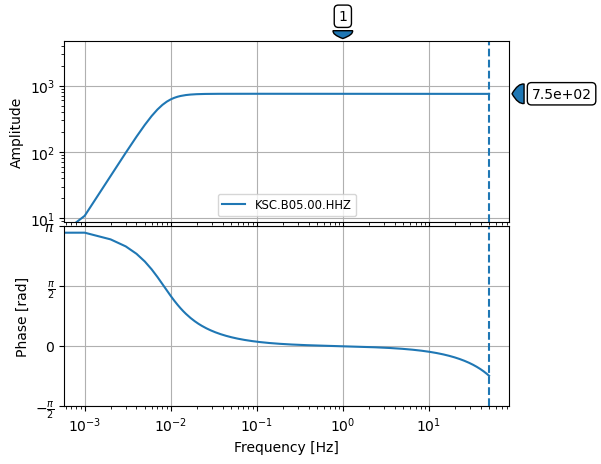

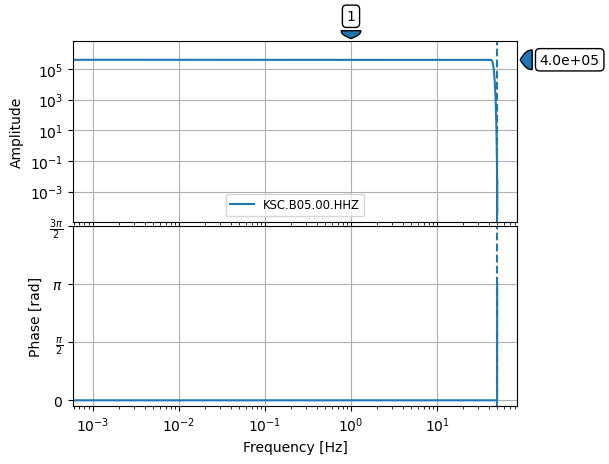

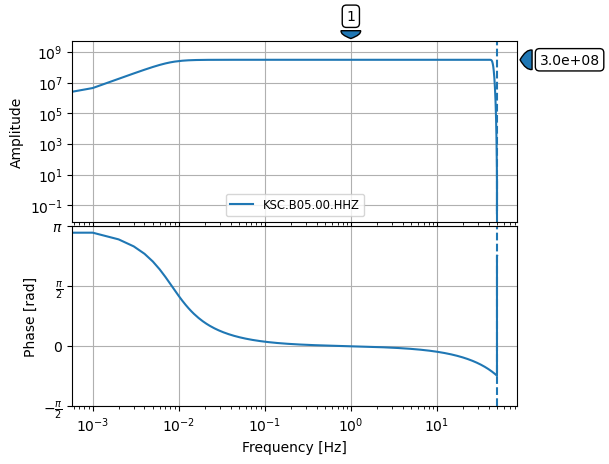

In [40]:
inv_sensor.plot_response(min_freq=0.001, output="VEL");
inv_digitizer.plot_response(min_freq=0.001, output="VEL");
inv_combined.plot_response(min_freq=0.001, output="VEL");

In [41]:
inv_sensor.write("B05_sensor.xml", format="STATIONXML")
inv_digitizer.write("B05_digitizer.xml", format="STATIONXML")
inv_combined.write("B05_combined.xml", format="STATIONXML")

## Step 5 — Quick check: read back the StationXML

In [42]:
from obspy import read_inventory

inv2 = read_inventory('B05_combined.xml')
print(inv2)

Inventory created at 2026-03-03T18:23:25.732325Z
	Created by: ObsPy 1.4.2
		    https://www.obspy.org
	Sending institution: NRL via ObsPy
	Contains:
		Networks (1):
			KSC
		Stations (1):
			KSC.B05 (NRL)
		Channels (1):
			KSC.B05.00.HHZ


## What to submit

Submit your notebook **and** the generated StationXML file.

### Your short note (2–4 sentences)
At the end of your notebook, include a short note:
- Which stations successfully got responses from the NRL?
- Which stations did not, and why (missing mapping, missing instrument info, etc.)?

# add notes below...

Only stations B05, B14, B24, and B29 had NRL responses. The others id not because they were missing either a digitizer or a seismometer label in the dataframe.